In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ۱. بارگذاری فایل CSV
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# ۲. مشاهده ۵ ردیف اول
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# بررسی اطلاعات کلی و نوع ستون‌ها
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# تبدیل فواصلی خالی به NaN و سپس تبدیل نوع ستون به عدد
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')

# پر کردن مقادیر مفقود (NaN) با صفر یا حذف آن‌ها
df['TotalCharges'].fillna(0, inplace=True)

# تبدیل ستون هدف (Churn) به متغیر عددی (0 و 1) برای مدلسازی‌های بعدی
df['Churn_Numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("پاک‌سازی با موفقیت انجام شد! تعداد مقادیر مفقود باقی‌مانده:")
print(df['TotalCharges'].isnull().sum())

پاک‌سازی با موفقیت انجام شد! تعداد مقادیر مفقود باقی‌مانده:
0


/tmp/ipykernel_1172/602710918.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


/tmp/ipykernel_1172/2794603051.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='InternetService', y='Churn_Numeric', palette='viridis')


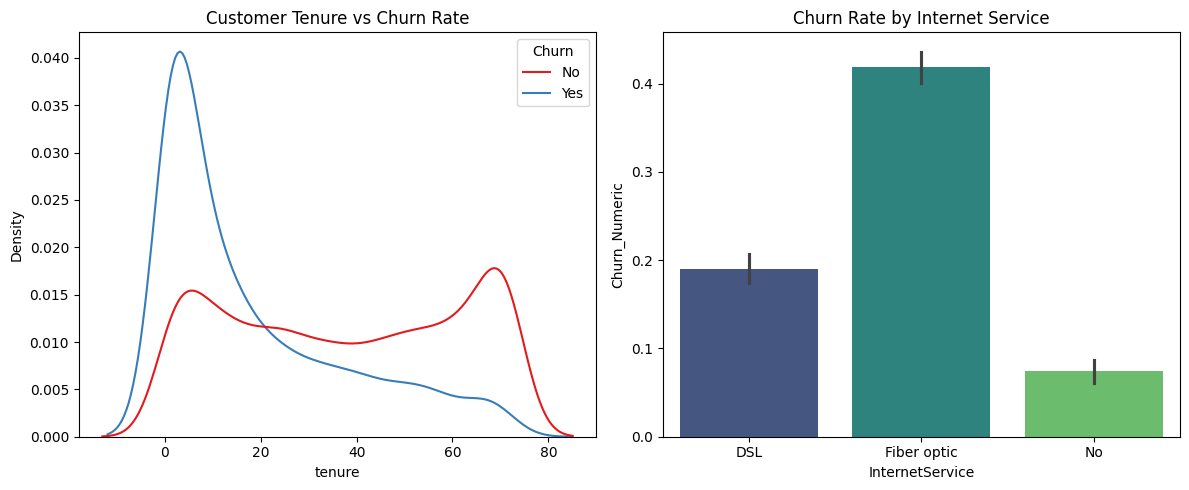

In [7]:
plt.figure(figsize=(12, 5))

# نمودار ۱: بررسی رابطه سابقه حضور (Tenure) با ریزش
plt.subplot(1, 2, 1)
sns.kdeplot(data=df, x='tenure', hue='Churn', common_norm=False, palette='Set1')
plt.title('Customer Tenure vs Churn Rate')

# نمودار ۲: نرخ ریزش بر اساس نوع اینترنت
plt.subplot(1, 2, 2)
sns.barplot(data=df, x='InternetService', y='Churn_Numeric', palette='viridis')
plt.title('Churn Rate by Internet Service')

plt.tight_layout()
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ۱. حذف ستون‌های غیرضروری (مثل شناسه مشتری)
X = df.drop(columns=['customerID', 'Churn', 'Churn_Numeric'])
y = df['Churn_Numeric']

# ۲. تبدیل متغیرهای متنی به عددی (One-Hot Encoding)
X_encoded = pd.get_dummies(X, drop_first=True)

# ۳. تقسیم داده‌ها به دو بخش آموزش (80%) و تست (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# ۴. استانداردسازی داده‌های عددی (Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"تعداد ویژگی‌ها پس از Encoding: {X_encoded.shape[1]}")
print(f"تعداد داده‌های آموزش: {len(X_train)} | تعداد داده‌های تست: {len(X_test)}")

تعداد ویژگی‌ها پس از Encoding: 30
تعداد داده‌های آموزش: 5634 | تعداد داده‌های تست: 1409


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# ۱. آموزش مدل رگرسیون لوجستیک
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

# ۲. آموزش مدل راندوم فورست
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

# ۳. ارزیابی اولیه
print("=== گزارش عملکرد Logistic Regression ===")
print(classification_report(y_test, y_pred_log))

print("\n=== گزارش عملکرد Random Forest ===")
print(classification_report(y_test, y_pred_rf))

=== گزارش عملکرد Logistic Regression ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


=== گزارش عملکرد Random Forest ===
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



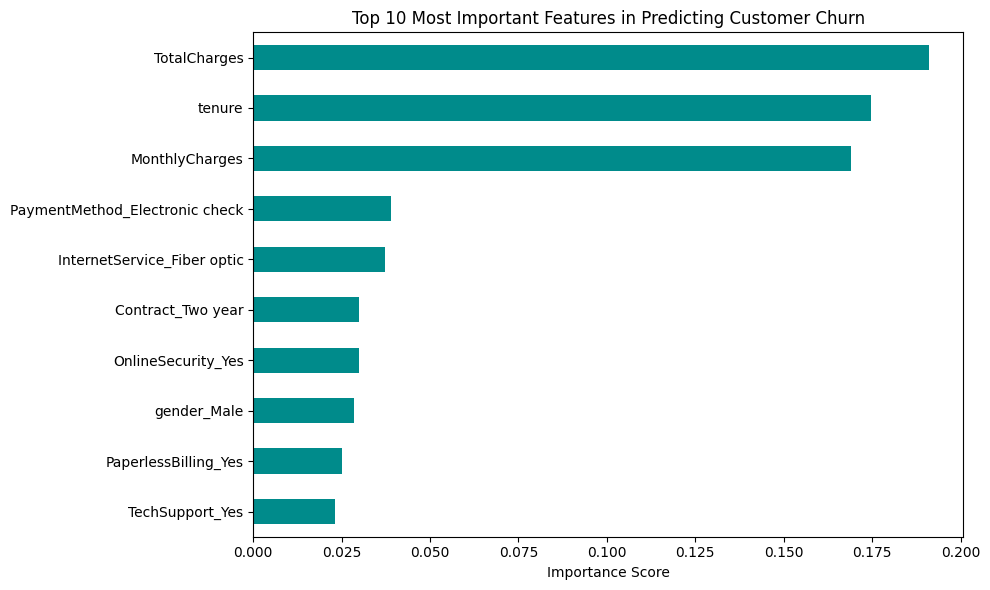

In [10]:
import matplotlib.pyplot as plt

# استخراج میزان اهمیت متغیرها از مدل Random Forest
importances = pd.Series(rf_model.feature_importances_, index=X_encoded.columns)
top_10_features = importances.nlargest(10)

plt.figure(figsize=(10, 6))
top_10_features.sort_values().plot(kind='barh', color='darkcyan')
plt.title('Top 10 Most Important Features in Predicting Customer Churn')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [11]:
# محاسبه احتمال ریزش برای تمامی مشتریان
all_data_scaled = scaler.transform(X_encoded)
df['Churn_Probability'] = rf_model.predict_proba(all_data_scaled)[:, 1]

# برچسب‌گذاری ریسک
df['Risk_Level'] = pd.cut(
    df['Churn_Probability'],
    bins=[0, 0.3, 0.7, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# ذخیره خروجی جهت استفاده در Power BI
df.to_csv('churn_predictions_for_powerbi.csv', index=False)
print("فایل churn_predictions_for_powerbi.csv با موفقیت ساخته شد!")

فایل churn_predictions_for_powerbi.csv با موفقیت ساخته شد!


┌─────────────────────────────────────────────────────────┐
│ 📊 KPI 1: Total Customers        : 7,043               │
│ 📉 KPI 2: Overall Churn Rate     : 26.54%               │
│ 💰 KPI 3: Total Lost Revenue     : $2,862,926.90       │
│ 🚨 KPI 4: High-Risk Customers    : 1,379               │
└─────────────────────────────────────────────────────────┘


/tmp/ipykernel_1172/40460352.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contract_churn, x='Contract', y='Churn_Numeric', ax=axes[0, 0], palette='Reds_r')
/tmp/ipykernel_1172/40460352.py:39: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df, x='tenure', hue='Churn', common_norm=False, ax=axes[0, 1], palette=['#2ecc71', '#e74c3c'], shade=True)
/tmp/ipykernel_1172/40460352.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=risk_counts, x='Risk_Level', y='Count', ax=axes[1, 0], palette=['#2ecc71', '#f39c12', '#e74c3c'])
/tmp/ipykernel_1172/404603

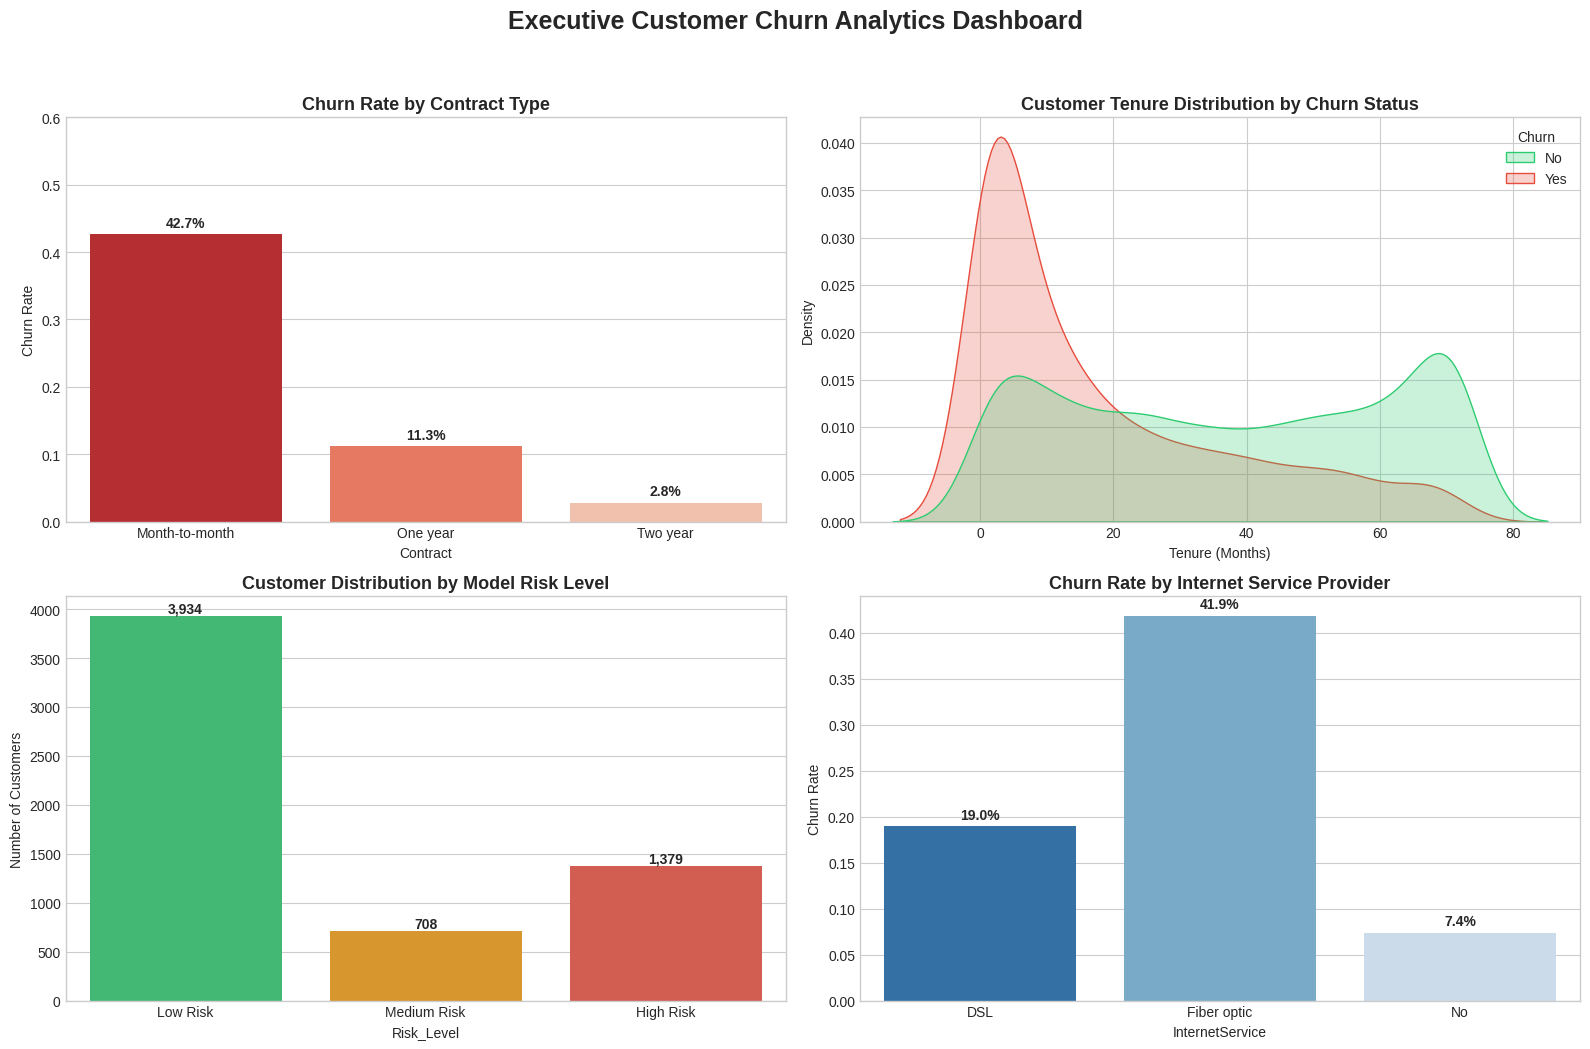

In [12]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ==========================================
# ۱. محاسبه کارت‌های KPI (Key Performance Indicators)
# ==========================================
total_customers = len(df)
churn_rate = (df['Churn_Numeric'].mean()) * 100
total_lost_revenue = df[df['Churn'] == 'Yes']['TotalCharges'].sum()
high_risk_count = len(df[df['Risk_Level'] == 'High Risk'])

print("┌─────────────────────────────────────────────────────────┐")
print(f"│ 📊 KPI 1: Total Customers        : {total_customers:,}               │")
print(f"│ 📉 KPI 2: Overall Churn Rate     : {churn_rate:.2f}%               │")
print(f"│ 💰 KPI 3: Total Lost Revenue     : ${total_lost_revenue:,.2f}       │")
print(f"│ 🚨 KPI 4: High-Risk Customers    : {high_risk_count:,}               │")
print("└─────────────────────────────────────────────────────────┘")


# ==========================================
# ۲. ساخت نمودارهای تحلیلی (Static Plots با Seaborn)
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Executive Customer Churn Analytics Dashboard', fontsize=18, fontweight='bold', y=0.98)

# نمودار ۱: نرخ ریزش بر اساس نوع قرارداد
contract_churn = df.groupby('Contract')['Churn_Numeric'].mean().reset_index()
sns.barplot(data=contract_churn, x='Contract', y='Churn_Numeric', ax=axes[0, 0], palette='Reds_r')
axes[0, 0].set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Churn Rate')
axes[0, 0].set_ylim(0, 0.6)
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

# نمودار ۲: رابطه سابقه حضور (Tenure) با ریزش
sns.kdeplot(data=df, x='tenure', hue='Churn', common_norm=False, ax=axes[0, 1], palette=['#2ecc71', '#e74c3c'], shade=True)
axes[0, 1].set_title('Customer Tenure Distribution by Churn Status', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Tenure (Months)')

# نمودار ۳: توزیع سطوح ریسک (Risk Level Categories)
risk_counts = df['Risk_Level'].value_counts().reset_index()
risk_counts.columns = ['Risk_Level', 'Count']
sns.barplot(data=risk_counts, x='Risk_Level', y='Count', ax=axes[1, 0], palette=['#2ecc71', '#f39c12', '#e74c3c'])
axes[1, 0].set_title('Customer Distribution by Model Risk Level', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Number of Customers')
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

# نمودار ۴: نرخ ریزش بر اساس سرویس اینترنت
internet_churn = df.groupby('InternetService')['Churn_Numeric'].mean().reset_index()
sns.barplot(data=internet_churn, x='InternetService', y='Churn_Numeric', ax=axes[1, 1], palette='Blues_r')
axes[1, 1].set_title('Churn Rate by Internet Service Provider', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Churn Rate')
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f"{p.get_height()*100:.1f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('executive_dashboard_summary.png', dpi=300, bbox_inches='tight')
plt.show()


# ==========================================
# ۳. جدول تعاملی ۱۰ مشتری اول با بالاترین ریسک ریزش (Plotly Table)
# ==========================================
high_risk_df = df[df['Risk_Level'] == 'High Risk'].sort_values(by='Churn_Probability', ascending=False).head(10)

fig_table = go.Figure(data=[go.Table(
    header=dict(
        values=['Customer ID', 'Contract', 'Monthly Charges ($)', 'Churn Probability', 'Risk Level'],
        fill_color='#2c3e50',
        align='left',
        font=dict(color='white', size=12, family='Arial')
    ),
    cells=dict(
        values=[
            high_risk_df['customerID'],
            high_risk_df['Contract'],
            high_risk_df['MonthlyCharges'],
            high_risk_df['Churn_Probability'].apply(lambda x: f"{x*100:.1f}%"),
            high_risk_df['Risk_Level']
        ],
        fill_color=[['#fadbd8']*len(high_risk_df)],  # رنگ قرمز روشن برای هایلایت کردن ریسک بالا
        align='left',
        font=dict(color='black', size=11, family='Arial')
    )
)])

fig_table.update_layout(
    title=' Top 10 High-Risk Customers Action List (for Marketing Team)',
    margin=dict(l=10, r=10, t=40, b=10)
)

fig_table.show()